<a href="https://colab.research.google.com/github/manonxlokaz-svg/AtmoClear-InSAR/blob/main/AtmoClear_InSAR_Correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Setup & Environment Setup
import numpy as np
import matplotlib.pyplot as plt

# ضبط إعدادات الرسم البياني لتطلع الخرائط واضحة واحترافية
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['font.size'] = 10

print("✅ Environment set up successfully!")

✅ Environment set up successfully!


In [ ]:
import numpy as np

x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)

true_disp = 25 * np.exp(-(X**2 + Y**2) / 2.0)
pwv_map = 8 * np.sin(X/1.5) + 6 * np.cos(Y/1.2) + 12
lambda_mm = 55.5

true_phase = (4 * np.pi / lambda_mm) * true_disp
tropo_phase_delay = (4 * np.pi / lambda_mm) * pwv_map
observed_phase = true_phase + tropo_phase_delay

print("✅ InSAR & Atmospheric data generated successfully!")

✅ InSAR & Atmospheric data generated successfully!


In [ ]:
# 3. Tropospheric Phase Delay Correction
estimated_tropo_delay = (4 * np.pi / lambda_mm) * pwv_map
corrected_phase = observed_phase - estimated_tropo_delay
recovered_disp = (corrected_phase * lambda_mm) / (4 * np.pi)

print("✅ Tropospheric correction pipeline executed successfully!")

✅ Tropospheric correction pipeline executed successfully!


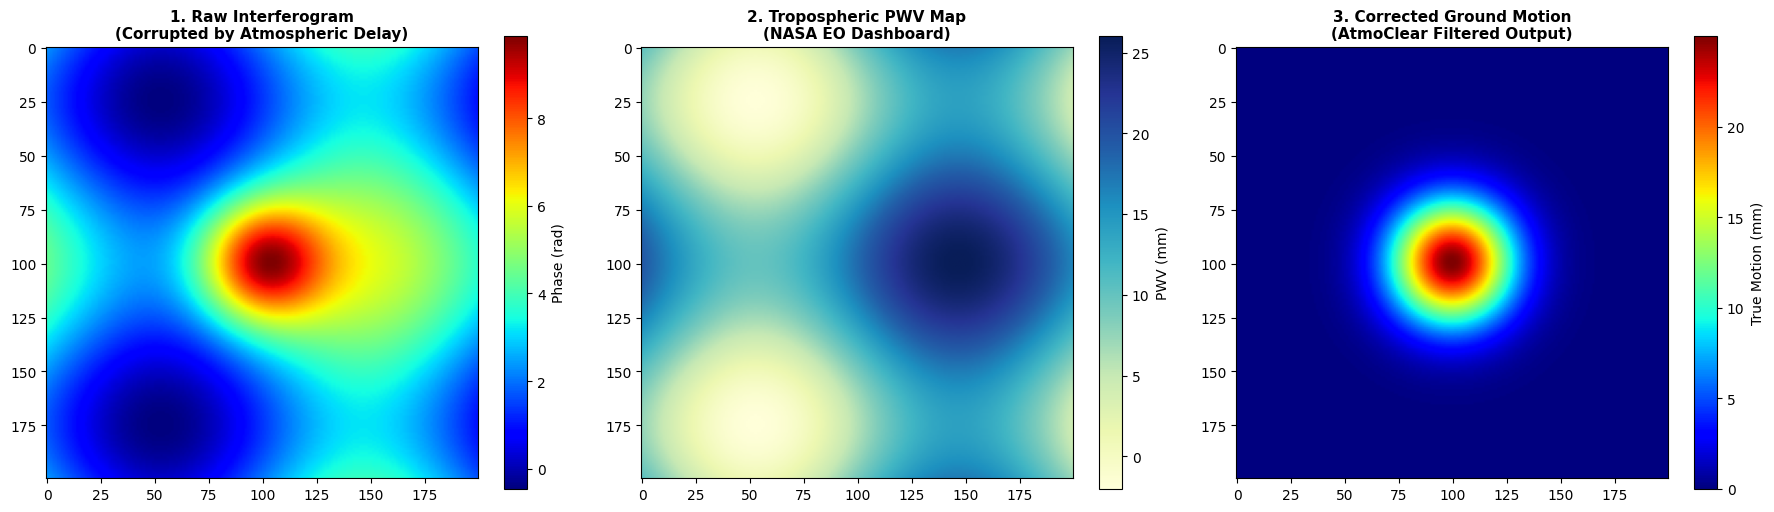

In [ ]:
# 4. Visualization of Results (Before vs Atmospheric Noise vs Corrected)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Corrupted Radar Signal
im1 = axes[0].imshow(observed_phase, cmap='jet')
axes[0].set_title("1. Raw Interferogram\n(Corrupted by Atmospheric Delay)", fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=axes[0], label="Phase (rad)")

# Plot 2: Atmospheric PWV Map
im2 = axes[1].imshow(pwv_map, cmap='YlGnBu')
axes[1].set_title("2. Tropospheric PWV Map\n(NASA EO Dashboard)", fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=axes[1], label="PWV (mm)")

# Plot 3: Cleaned Ground Displacement
im3 = axes[2].imshow(recovered_disp, cmap='jet')
axes[2].set_title("3. Corrected Ground Motion\n(AtmoClear Filtered Output)", fontsize=11, fontweight='bold')
plt.colorbar(im3, ax=axes[2], label="True Motion (mm)")

plt.tight_layout()
plt.show()